In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv('student_performance_1000.csv')

In [3]:
print(df.columns)

Index(['StudentID', 'Name', 'Gender', 'AttendanceRate', 'StudyHoursPerWeek',
       'PreviousGrade', 'ExtracurricularActivities', 'ParentalSupport',
       'FinalGrade', 'Study Hours', 'Attendance (%)', 'Online Classes Taken'],
      dtype='object')


In [4]:
df.isnull()

,StudentID,Name,Gender,AttendanceRate,StudyHoursPerWeek,PreviousGrade,ExtracurricularActivities,ParentalSupport,FinalGrade,Study Hours,Attendance (%),Online Classes Taken
0,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,True,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
995,True,False,False,False,False,True,False,False,False,False,False,False
996,False,False,False,False,True,False,False,False,False,False,False,False
997,False,True,False,False,False,False,False,False,False,False,False,False
998,False,False,False,False,False,False,False,False,False,False,False,False


In [5]:
df.isnull().sum()

StudentID                    40
Name                         34
Gender                       48
AttendanceRate               40
StudyHoursPerWeek            50
PreviousGrade                33
ExtracurricularActivities    43
ParentalSupport              22
FinalGrade                   40
Study Hours                  24
Attendance (%)               41
Online Classes Taken         25
dtype: int64

In [6]:
df = df.drop(['StudentID','Name'], axis=1)

In [7]:
df.columns

Index(['Gender', 'AttendanceRate', 'StudyHoursPerWeek', 'PreviousGrade',
       'ExtracurricularActivities', 'ParentalSupport', 'FinalGrade',
       'Study Hours', 'Attendance (%)', 'Online Classes Taken'],
      dtype='object')

In [8]:
df.isnull().sum()

Gender                       48
AttendanceRate               40
StudyHoursPerWeek            50
PreviousGrade                33
ExtracurricularActivities    43
ParentalSupport              22
FinalGrade                   40
Study Hours                  24
Attendance (%)               41
Online Classes Taken         25
dtype: int64

In [9]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
df[num_cols]= df[num_cols].fillna(df[num_cols].mean())

In [10]:
df.isnull().sum()

Gender                       48
AttendanceRate                0
StudyHoursPerWeek             0
PreviousGrade                 0
ExtracurricularActivities     0
ParentalSupport              22
FinalGrade                    0
Study Hours                   0
Attendance (%)                0
Online Classes Taken         25
dtype: int64

In [11]:
cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

C:\Users\Rohit Singh\AppData\Local\Temp\ipykernel_18948\3660225717.py:3: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].fillna(df[col].mode()[0])


In [12]:
print(df["Gender"].unique())  # Print the unique values in the 'Gender' column

['Male' 'Female']


In [13]:
df["Gender"].value_counts()  # Count the occurrences of each category in

Gender
Male      549
Female    451
Name: count, dtype: int64

C:\Users\Rohit Singh\AppData\Local\Temp\ipykernel_18948\1078225412.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Gender', data=df, palette=colors, edgecolor='white', linewidth=1.5)


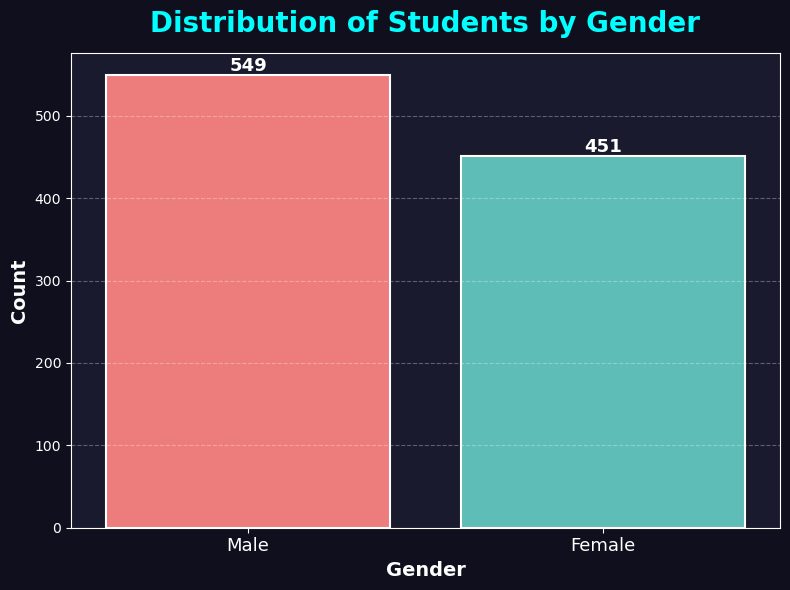

In [14]:
plt.style.use('dark_background')  # stylish dark theme

fig, ax = plt.subplots(figsize=(8, 6))

colors = ['#FF6B6B', '#4ECDC4']  # alag alag color har bar ke liye

ax = sns.countplot(x='Gender', data=df, palette=colors, edgecolor='white', linewidth=1.5)

# Har bar ke upar value dikhana
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', 
                fontsize=13, fontweight='bold', color='white')

plt.title('Distribution of Students by Gender', fontsize=20, fontweight='bold', color='cyan', pad=15)
plt.xlabel('Gender', fontsize=14 , fontweight='bold')
plt.ylabel('Count', fontsize=14, fontweight='bold')
plt.xticks([0, 1], ['Male', 'Female'] , fontsize=13)  # x-axis labels ko customize karna

ax.set_facecolor('#1a1a2e')
fig.patch.set_facecolor('#0f0f1e')
ax.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

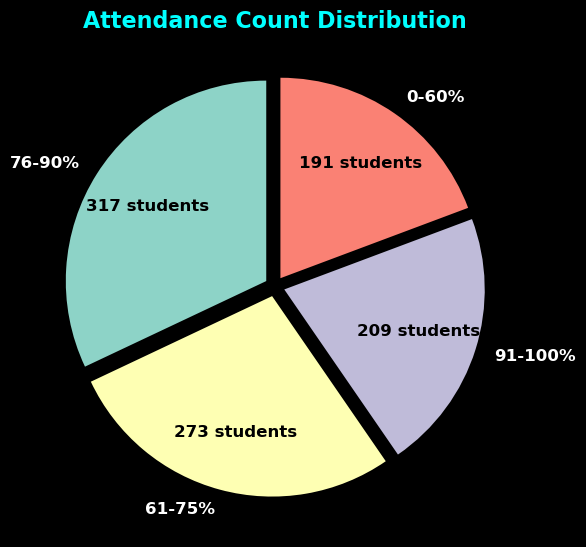

In [15]:
attendance_group = pd.cut(
    df["Attendance (%)"],
    bins=[0, 60, 75, 90, 100],
    labels=["0-60%", "61-75%", "76-90%", "91-100%"]
)

attendance_counts = attendance_group.value_counts()

import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
wedges, texts, autotexts = plt.pie(
    attendance_counts,
    labels=attendance_counts.index,
    autopct=lambda pct: f"{int(round(pct/100*attendance_counts.sum()))} students",
    startangle=90,
    explode=[0.05, 0.05, 0.05, 0.05],
    pctdistance=0.7,
    textprops={'color':'white', 'fontsize':12, 'weight':'bold'}
)

for text in texts:
    text.set_color('white')
    text.set_fontsize(12)
    text.set_weight('bold')

for autotext in autotexts:
    autotext.set_color('black')
    autotext.set_fontsize(12)
    autotext.set_weight('bold')

plt.title("Attendance Count Distribution", color='cyan', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

C:\Users\Rohit Singh\AppData\Local\Temp\ipykernel_18948\999072737.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


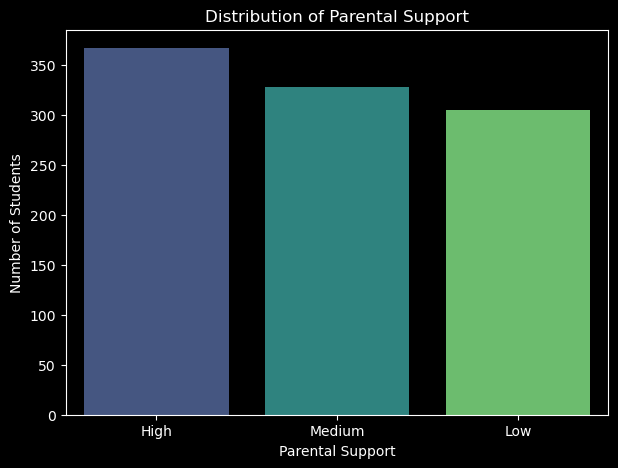

In [16]:

plt.figure(figsize=(7,5))

sns.countplot(
    x="ParentalSupport",
    data=df,
    palette="viridis"
)

plt.title("Distribution of Parental Support")
plt.xlabel("Parental Support")
plt.ylabel("Number of Students")

plt.show()

C:\Users\Rohit Singh\AppData\Local\Temp\ipykernel_18948\2328990290.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Gender', data=temp_df, palette=colors_gender, edgecolor='white', linewidth=1, ax=ax1)
C:\Users\Rohit Singh\AppData\Local\Temp\ipykernel_18948\2328990290.py:88: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


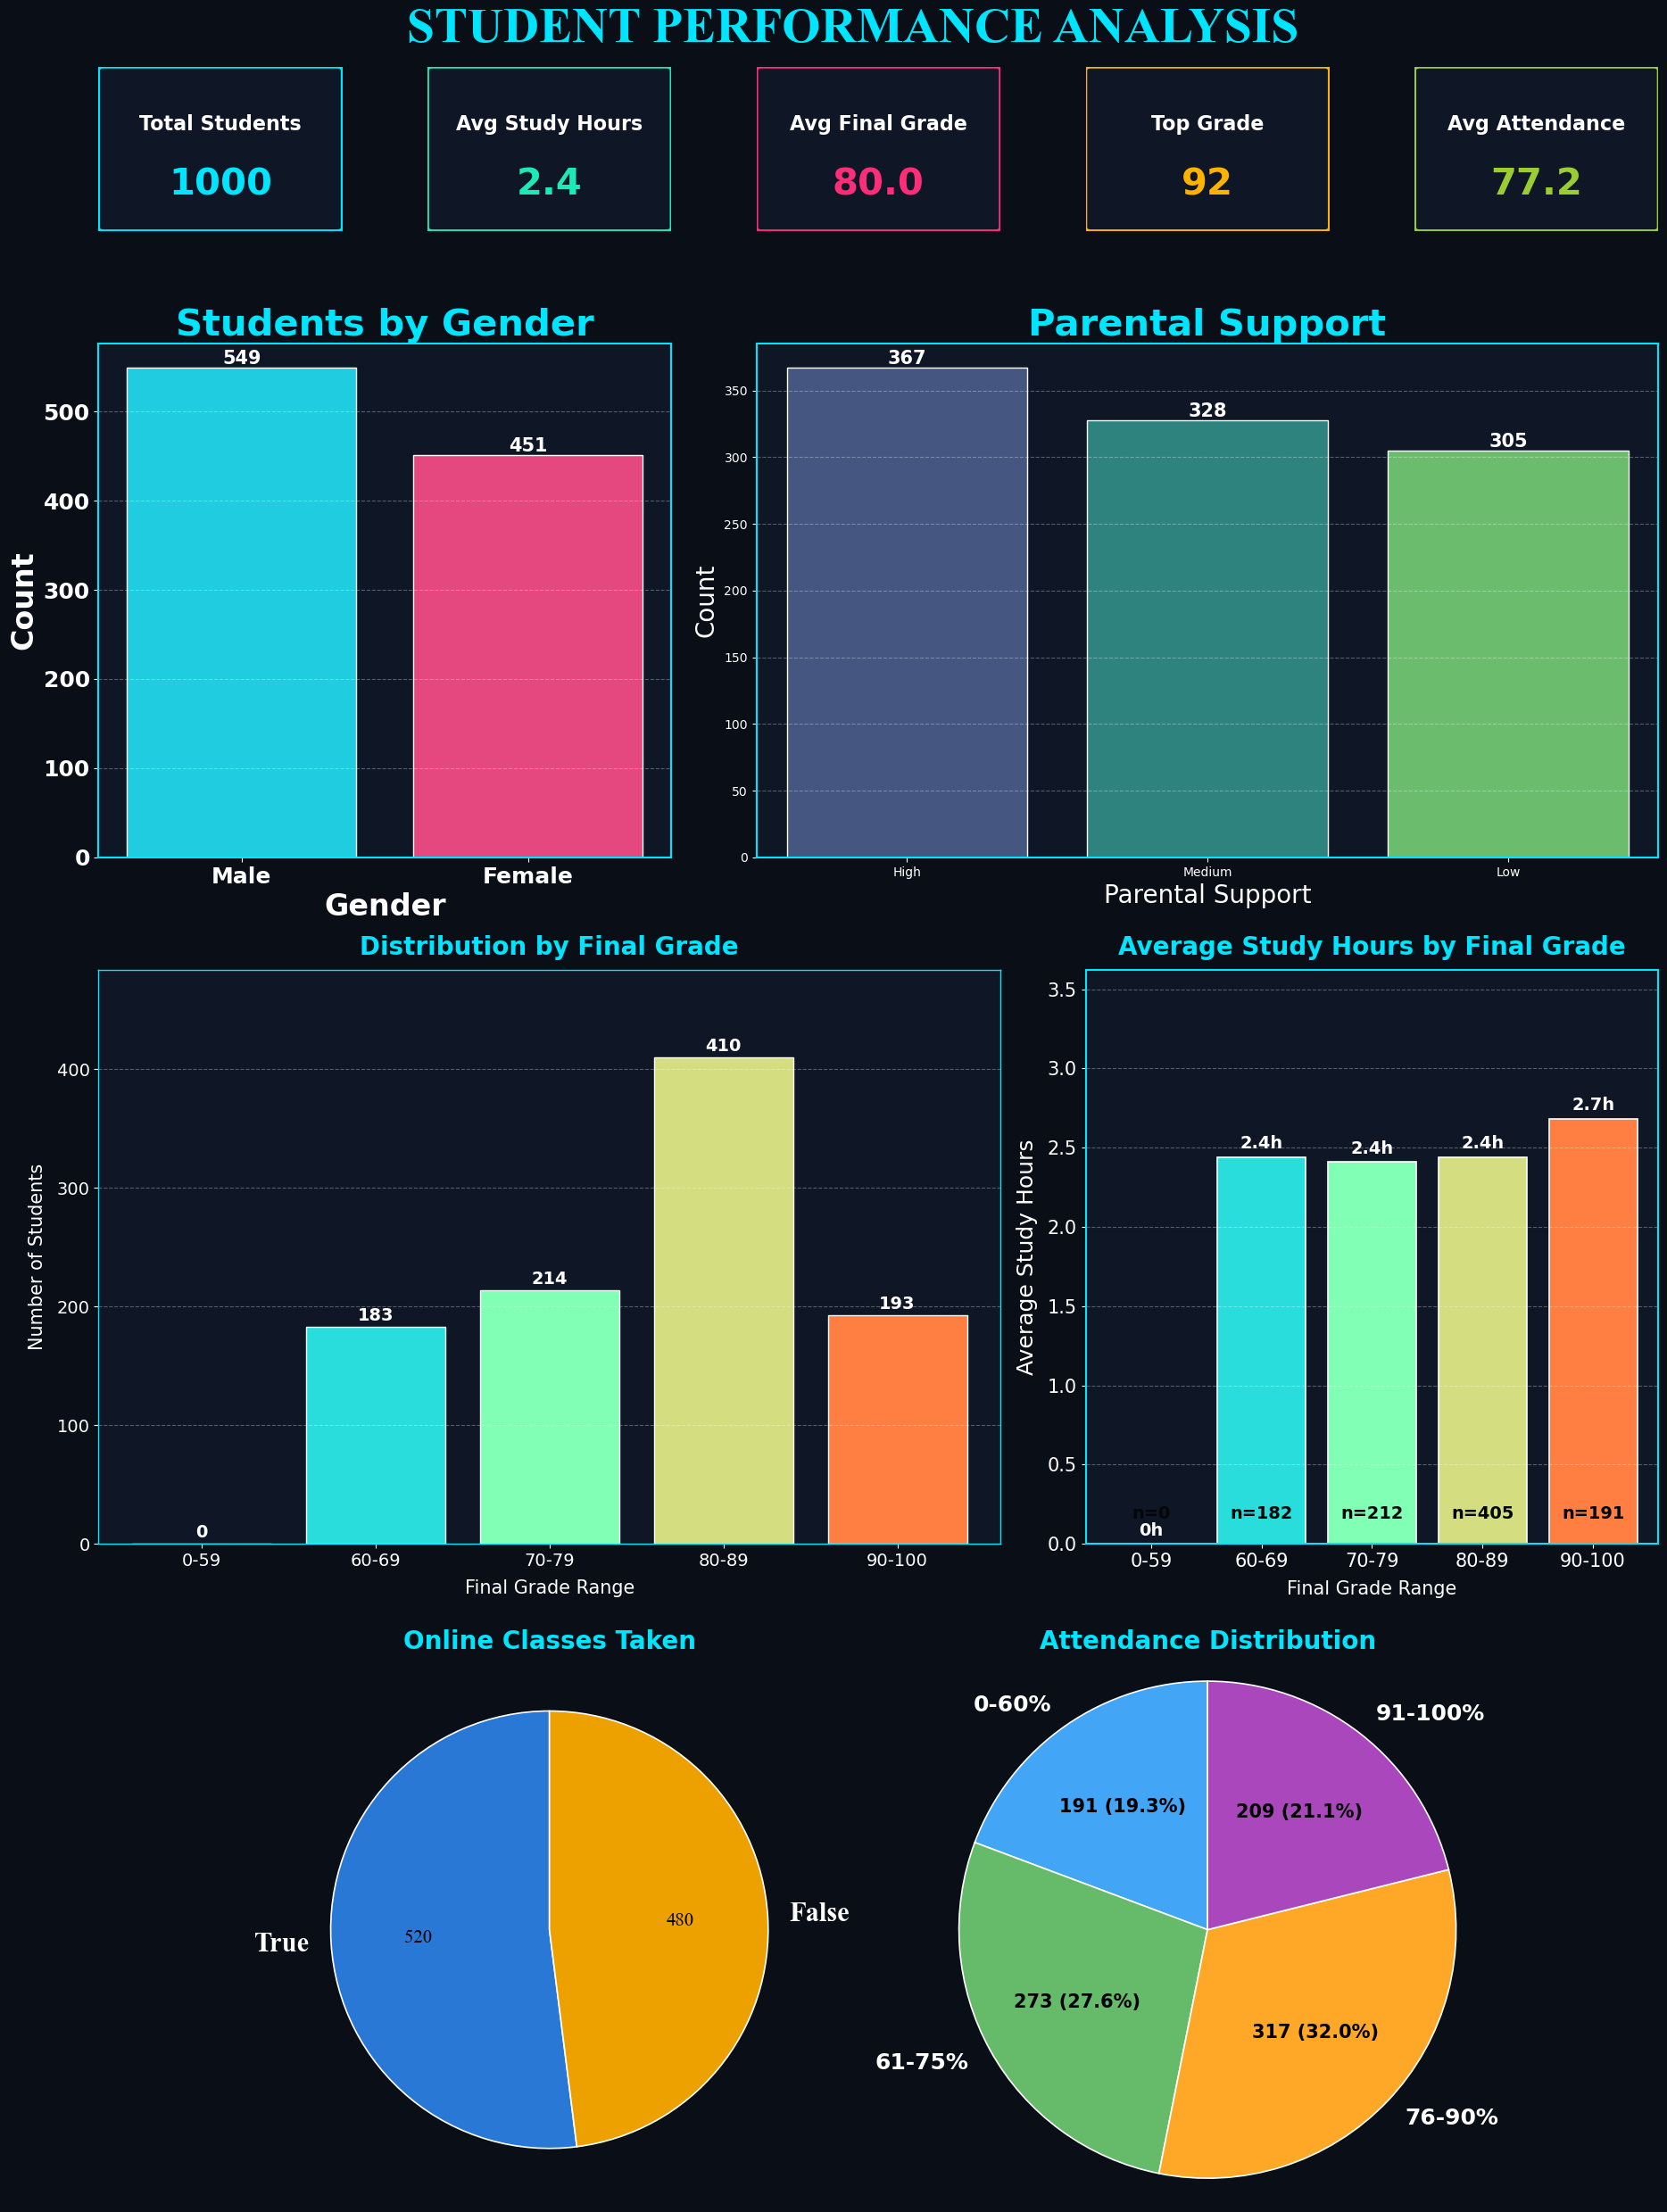

In [ ]:
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyBboxPatch

plt.style.use('dark_background')


fig = plt.figure(figsize=(19, 28))
fig.patch.set_facecolor('#0a0e17')
# changed to 5 columns to accommodate 5 KPI cards and an extra plot row
gs = gridspec.GridSpec(4, 5, figure=fig, height_ratios=[0.30, 0.94, 1.05, 1.00], hspace=0.25, wspace=0.35)

# ---------- TITLE ----------
fig.text(0.5, 0.92, 'STUDENT PERFORMANCE ANALYSIS',
          ha='center', fontsize=40, fontweight='bold', color='#00e5ff', fontfamily='Times New Roman')

# ---------- KPI CARDS ----------
kpi_data = [
    ('Total Students', f"{len(df)}", '#00e5ff'),
    ('Avg Study Hours', f"{df['Study Hours'].mean():.1f}" if 'Study Hours' in df.columns else 'N/A', '#1de9b6'),
    ('Avg Final Grade', f"{df['FinalGrade'].mean():.1f}" if 'FinalGrade' in df.columns else 'N/A', '#ff2d78'),
    ('Top Grade', f"{df['FinalGrade'].max():.0f}" if 'FinalGrade' in df.columns else 'N/A', '#ffb300'),
    ('Avg Attendance', f"{df['Attendance (%)'].mean():.1f}" if 'Attendance (%)' in df.columns else 'N/A', '#9acd32'),
]

from matplotlib.patches import FancyBboxPatch

for i, (label, value, color) in enumerate(kpi_data):
    ax = fig.add_subplot(gs[0, i])
    ax.set_facecolor('#0f1626')

    ax.set_xticks([])
    ax.set_yticks([])

    for spine in ax.spines.values():
        spine.set_visible(False)

    fancy_box = FancyBboxPatch(
        (0.02, 0.02), 0.96, 0.96,
        boxstyle="round,pad=0.02",
        edgecolor=color,
        facecolor='none',
        linewidth=2.5,
        transform=ax.transAxes
    )

    ax.add_patch(fancy_box)

    ax.text(0.5, 0.65, label,
            ha='center', va='center',
            fontsize=16, fontweight='bold', color='white')

    ax.text(0.5, 0.28, value,
            ha='center', va='center',
            fontsize=30, fontweight='bold', color=color)

# ---------- Gender Countplot ----------
ax1 = fig.add_subplot(gs[1, 0:2])
colors_gender = ['#00e5ff', '#ff2d78']
temp_df = df.copy()
if 'Gender' in temp_df.columns and temp_df['Gender'].dtype.kind in 'biufc' and set(temp_df['Gender'].dropna().unique()) <= {0, 1}:
    temp_df['Gender'] = temp_df['Gender'].map({0: 'Male', 1: 'Female'})
sns.countplot(x='Gender', data=temp_df, palette=colors_gender, edgecolor='white', linewidth=1, ax=ax1)
for p in ax1.patches:
    ax1.annotate(f"{int(p.get_height())}", (p.get_x() + p.get_width() / 2, p.get_height()),
                 ha='center', va='bottom', fontsize=15, fontweight='bold', color='white')
ax1.set_title('Students by Gender', fontsize=30, fontweight='bold', color='#00e5ff')
ax1.set_facecolor('#0f1626')
ax1.grid(axis='y', linestyle='--', alpha=0.3)
for spine in ax1.spines.values():
    spine.set_edgecolor('#00e5ff')
    spine.set_linewidth(1.5)
    
ax1.set_xlabel("Gender", fontsize=24, fontweight='bold', color='white')
ax1.set_ylabel("Count", fontsize=24, fontweight='bold', color='white')

for label in ax1.get_xticklabels():
    label.set_fontsize(18)
    label.set_fontweight('bold')
    label.set_color('white')

for label in ax1.get_yticklabels():
    label.set_fontsize(18)
    label.set_fontweight('bold')
    label.set_color('white')    

# ---------- Parental Support Countplot ----------
ax_parent = fig.add_subplot(gs[1, 2:5])
sns.countplot(
    x='ParentalSupport',
    data=df,
    palette='viridis',
    edgecolor='white',
    linewidth=1,
    ax=ax_parent
)
for p in ax_parent.patches:
    ax_parent.annotate(f"{int(p.get_height())}", (p.get_x() + p.get_width() / 2, p.get_height()),
                       ha='center', va='bottom', fontsize=15, fontweight='bold', color='white')
ax_parent.set_title('Parental Support', fontsize=30, fontweight='bold', color='#00e5ff')
ax_parent.set_xlabel('Parental Support', fontsize=20, color='white')
ax_parent.set_ylabel('Count', fontsize=20, color='white')
ax_parent.set_facecolor('#0f1626')
ax_parent.grid(axis='y', linestyle='--', alpha=0.3)
for spine in ax_parent.spines.values():
    spine.set_edgecolor('#00e5ff')
    spine.set_linewidth(1.5)

# ---------- FinalGrade Distribution ----------
ax2 = fig.add_subplot(gs[2, 0:3])  # Adjusted to span the remaining columns 
grade_bins = [-0.01, 59, 69, 79, 89, 100]
grade_labels = ['0-59', '60-69', '70-79', '80-89', '90-100']
plot_df = df.copy()
grades = []

if 'FinalGrade' in plot_df.columns:
    plot_df['FinalGradeNumeric'] = pd.to_numeric(plot_df['FinalGrade'], errors='coerce')
    plot_df = plot_df[plot_df['FinalGradeNumeric'].between(0, 100)]
    plot_df['FinalGradeRange'] = pd.cut(
        plot_df['FinalGradeNumeric'],
        bins=grade_bins,
        labels=grade_labels,
        include_lowest=True
    )
    grade_counts = plot_df['FinalGradeRange'].value_counts().reindex(grade_labels, fill_value=0)
    colors_rainbow = sns.color_palette('rainbow', n_colors=len(grade_labels))

    bars = ax2.bar(
        grade_labels,
        grade_counts.values,
        color=colors_rainbow,
        edgecolor='white',
        linewidth=1
    )
    max_count = max(grade_counts.max(), 1)
    ax2.set_ylim(0, max_count * 1.18)
    ax2.bar_label(
        bars,
        labels=[str(int(v)) for v in grade_counts.values],
        padding=2 ,
        fontsize=14,
        fontweight='bold',
        color='white'
    )
else:
    plot_df = pd.DataFrame()
    colors_rainbow = sns.color_palette('rainbow', n_colors=len(grade_labels))

ax2.set_title('Distribution by Final Grade', fontsize=20, fontweight='bold', color='#00e5ff', pad=12)
ax2.set_facecolor('#0f1626')
ax2.set_xlabel('Final Grade Range', fontsize=15, color='white', labelpad=8)
ax2.set_ylabel('Number of Students', fontsize=15, color='white', labelpad=8)
ax2.tick_params(axis='x', labelrotation=0, labelsize=14, colors='white')
ax2.tick_params(axis='y', labelsize=14, colors='white')
ax2.margins(x=0.04)
ax2.grid(axis='y', linestyle='--', alpha=0.3)
for spine in ax2.spines.values():
    spine.set_edgecolor('#00e5ff')
    spine.set_linewidth(1)

# ---------- Average Study Hours by Grade Range ----------
ax3 = fig.add_subplot(gs[2, 3:5])
if not plot_df.empty and 'Study Hours' in plot_df.columns:
    plot_df['StudyHoursNumeric'] = pd.to_numeric(plot_df['Study Hours'], errors='coerce')
    study_plot_df = plot_df[
        plot_df['StudyHoursNumeric'].between(0, 24)
    ].dropna(subset=['FinalGradeRange', 'StudyHoursNumeric'])
    study_summary = study_plot_df.groupby('FinalGradeRange', observed=False)['StudyHoursNumeric'].agg(['mean', 'count'])
    study_summary = study_summary.reindex(grade_labels).fillna(0)

    bars = ax3.bar(
        grade_labels,
        study_summary['mean'].values,
        color=colors_rainbow,
        edgecolor='white',
        linewidth=1.2
    )
    max_hours = max(study_summary['mean'].max(), 1)
    ax3.set_ylim(0, max_hours * 1.35)
    ax3.bar_label(
        bars,
        labels=[f"{value:.1f}h" if count else "0h" for value, count in zip(study_summary['mean'], study_summary['count'])],
        padding=4,
        fontsize=14,
        fontweight='bold',
        color='white'
    )
    for index, count in enumerate(study_summary['count']):
        ax3.text(
            index,
            max_hours * 0.05,
            f"n={int(count)}",
            ha='center',
            va='bottom',
            fontsize=14,
            color="#040707",
            fontweight='bold'
        )

ax3.set_title('Average Study Hours by Final Grade', fontsize=20, fontweight='bold', color='#00e5ff', pad=12)
ax3.set_facecolor('#0f1626')
ax3.set_xlabel('Final Grade Range', fontsize=15, color='white', labelpad=8)
ax3.set_ylabel('Average Study Hours', fontsize=18, color='white', labelpad=8)
ax3.tick_params(axis='x', labelrotation=0, labelsize=15, colors='white')
ax3.tick_params(axis='y', labelsize=15, colors='white')
ax3.margins(x=0.04)
ax3.grid(axis='y', linestyle='--', alpha=0.3)
for spine in ax3.spines.values():
    spine.set_edgecolor('#00e5ff')
    spine.set_linewidth(1.5)

# ---------- Online Classes Taken pie chart ----------
ax4 = fig.add_subplot(gs[3, 0:3])
counts = df['Online Classes Taken'].value_counts()
labels = [str(label) for label in counts.index]
colors_pie = ['#2a78d6', '#eda100'] if len(counts) > 1 else ['#2a78d6']
wedges, texts, autotexts = ax4.pie(
    counts.values,
    labels=labels,
    autopct=lambda pct: f"{int(round(pct / 100 * counts.sum()))}",
    colors=colors_pie,
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.2},

)
# Bahar ke labels -> White
for text in texts:
    text.set_color('white')
    text.set_fontsize(22)
    text.set_weight('bold'),
    text.set_fontfamily('Times New Roman')

# Andar ki values -> Black
for autotext in autotexts:
    autotext.set_color('black')
    autotext.set_fontsize(15)
    autotext.set_fontfamily('Times New Roman')
   # autotext.set_weight('bold')
    

ax4.set_title('Online Classes Taken', fontsize=20, fontweight='bold', color='#00e5ff')
ax4.set_facecolor('#0f1626')

# ---------- Attendance Distribution pie chart ----------
ax_att = fig.add_subplot(gs[3, 2:5])
attendance_groups = pd.cut(
    df['Attendance (%)'].dropna(),
    bins=[0, 60, 75, 90, 100],
    labels=['0-60%', '61-75%', '76-90%', '91-100%'],
    include_lowest=True
)
attendance_counts = attendance_groups.value_counts().reindex(['0-60%', '61-75%', '76-90%', '91-100%']).fillna(0)
att_colors = ['#42a5f5', '#66bb6a', '#ffa726', '#ab47bc']
wedges, texts, autotexts = ax_att.pie(
    attendance_counts.values,
    labels=attendance_counts.index,
    autopct=lambda pct: f"{int(round(pct / 100 * attendance_counts.sum()))} ({pct:.1f}%)",
    colors=att_colors[:len(attendance_counts)],
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.2},
    
)
# Bahar ke labels -> White
for text in texts:
    text.set_color('white')
    text.set_fontsize(18)
    text.set_weight('bold')

# Andar ki values -> Black
for autotext in autotexts:
    autotext.set_color('black')
    autotext.set_fontsize(15)
    autotext.set_weight('bold')
    
ax_att.set_title('Attendance Distribution', fontsize=20, fontweight='bold', color='#00e5ff')
ax_att.axis('equal')
ax_att.set_facecolor('#0f1626')

fig.subplots_adjust(left=0.055, right=0.975, top=0.91, bottom=0.055, hspace=0.55, wspace=0.35)
plt.show()
